In [35]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn import svm
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR

from sklearn.metrics import mean_squared_error, r2_score,root_mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

In [4]:
df = pd.read_csv("car_price_dataset.csv", sep=";")

In [5]:
df.head(7)

,Brand,Model,Year,Engine_Size,Fuel_Type,Transmission,Mileage,Doors,Owner_Count,Price
0,Kia,Rio,2020,4.2,Diesel,Manual,289944,3,5,8501
1,Chevrolet,Malibu,2012,2.0,Hybrid,Automatic,5356,2,3,12092
2,Mercedes,GLA,2020,4.2,Diesel,Automatic,231440,4,2,11171
3,Audi,Q5,2023,2.0,Electric,Manual,160971,2,1,11780
4,Volkswagen,Golf,2003,2.6,Hybrid,Semi-Automatic,286618,3,3,2867
5,Toyota,Camry,2007,2.7,Petrol,Automatic,157889,4,4,7242
6,Honda,Civic,2010,3.4,Electric,Automatic,139584,3,1,11208


In [6]:
df.describe()

,Year,Engine_Size,Mileage,Doors,Owner_Count,Price
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,2011.543700,3.000560,149239.111800,3.497100,2.991100,8852.96440
std,6.897699,1.149324,86322.348957,1.110097,1.422682,3112.59681
min,2000.000000,1.000000,25.000000,2.000000,1.000000,2000.00000
25%,2006.000000,2.000000,74649.250000,3.000000,2.000000,6646.00000
50%,2012.000000,3.000000,149587.000000,3.000000,3.000000,8858.50000
75%,2017.000000,4.000000,223577.500000,4.000000,4.000000,11086.50000
max,2023.000000,5.000000,299947.000000,5.000000,5.000000,18301.00000


In [7]:
print(df.tail())
print(df.shape)
print(df.columns)

           Brand     Model  Year  ...  Doors Owner_Count Price
9995         Kia    Optima  2004  ...      2           4  8884
9996   Chevrolet    Impala  2002  ...      2           1  6240
9997         BMW  3 Series  2010  ...      5           1  9866
9998        Ford  Explorer  2002  ...      4           1  4084
9999  Volkswagen    Tiguan  2001  ...      3           3  3342

[5 rows x 10 columns]
(10000, 10)
Index(['Brand', 'Model', 'Year', 'Engine_Size', 'Fuel_Type', 'Transmission',
       'Mileage', 'Doors', 'Owner_Count', 'Price'],
      dtype='str')


In [8]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Brand         10000 non-null  str    
 1   Model         10000 non-null  str    
 2   Year          10000 non-null  int64  
 3   Engine_Size   10000 non-null  float64
 4   Fuel_Type     10000 non-null  str    
 5   Transmission  10000 non-null  str    
 6   Mileage       10000 non-null  int64  
 7   Doors         10000 non-null  int64  
 8   Owner_Count   10000 non-null  int64  
 9   Price         10000 non-null  int64  
dtypes: float64(1), int64(5), str(4)
memory usage: 781.4 KB
None


In [9]:
print(df.isnull().sum())

Brand           0
Model           0
Year            0
Engine_Size     0
Fuel_Type       0
Transmission    0
Mileage         0
Doors           0
Owner_Count     0
Price           0
dtype: int64


In [9]:
print(df["Brand"].value_counts())

Brand
Ford          1048
Audi          1038
Volkswagen    1020
Honda         1009
Chevrolet     1003
BMW            999
Hyundai        995
Kia            976
Toyota         970
Mercedes       942
Name: count, dtype: int64


In [10]:
print(df["Fuel_Type"].value_counts())

Fuel_Type
Electric    2625
Diesel      2512
Hybrid      2453
Petrol      2410
Name: count, dtype: int64


In [11]:
print(df["Transmission"].value_counts())

Transmission
Manual            3372
Automatic         3317
Semi-Automatic    3311
Name: count, dtype: int64


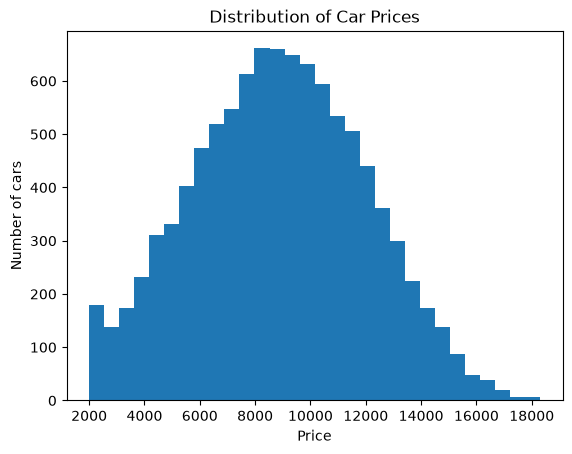

In [12]:
# 7. Price distribution


plt.hist(df["Price"], bins=30)
plt.xlabel("Price")
plt.ylabel("Number of cars")
plt.title("Distribution of Car Prices")
plt.show()


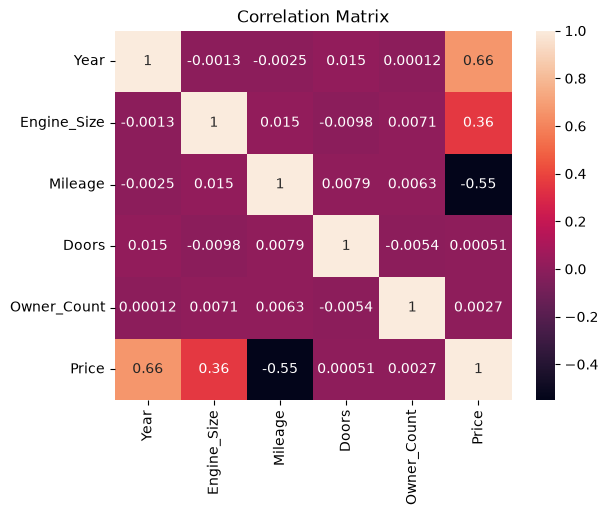

In [13]:
correlation = df.corr(numeric_only=True)

sns.heatmap(correlation, annot=True)

plt.title("Correlation Matrix")
plt.show()

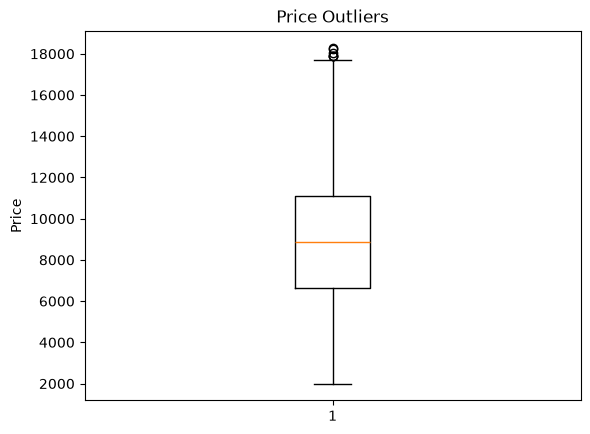

In [12]:
plt.boxplot(df["Price"])
plt.ylabel("Price")
plt.title("Price Outliers")
plt.show()

In [13]:
df_1 = pd.get_dummies(df,columns=["Brand", "Model","Transmission","Fuel_Type"],dtype=int)

In [14]:
print(df_1.head(5))

   Year  Engine_Size  ...  Fuel_Type_Hybrid  Fuel_Type_Petrol
0  2020          4.2  ...                 0                 0
1  2012          2.0  ...                 1                 0
2  2020          4.2  ...                 0                 0
3  2023          2.0  ...                 0                 0
4  2003          2.6  ...                 1                 0

[5 rows x 53 columns]


In [15]:
x = df_1.drop("Price", axis=1)
y = df_1["Price"]

In [16]:
print(x)

      Year  Engine_Size  ...  Fuel_Type_Hybrid  Fuel_Type_Petrol
0     2020          4.2  ...                 0                 0
1     2012          2.0  ...                 1                 0
2     2020          4.2  ...                 0                 0
3     2023          2.0  ...                 0                 0
4     2003          2.6  ...                 1                 0
...    ...          ...  ...               ...               ...
9995  2004          3.7  ...                 0                 0
9996  2002          1.4  ...                 0                 0
9997  2010          3.0  ...                 0                 1
9998  2002          1.4  ...                 1                 0
9999  2001          2.1  ...                 0                 0

[10000 rows x 52 columns]


In [17]:
x_full_train, x_test, y_train_full, y_test = train_test_split(x,y,test_size=0.2,random_state=42)
X_train, X_val, y_train, y_val = train_test_split(x_full_train, y_train_full, test_size=0.3, random_state=36)

In [18]:
log_reg = LinearRegression()
log_reg.fit(X_train, y_train)
log_reg_pred = log_reg.predict(X_val)

In [19]:
tree_clf = DecisionTreeRegressor()

# Finding the best hyperparameter through GridSearch.
hyper_params = {'max_depth':(None, 1, 2, 5, 10)}
clf = GridSearchCV(tree_clf, hyper_params)

clf.fit(X_train, y_train)
clf_pred = clf.predict(X_val)

In [24]:
from sklearn.ensemble import RandomForestRegressor

rf_clf = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

rf_params = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5]
}

rf_grid = GridSearchCV(
    rf_clf,
    rf_params,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None, 10, ...], 'min_samples_split': [2, 5], 'n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, 

In [25]:
print("Best Random Forest Parameters:")
print(rf_grid.best_params_)

Best Random Forest Parameters:
{'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}


In [29]:
# Predictions (already fit above) ---
log_reg_pred = log_reg.predict(X_val)
clf_pred = clf.predict(X_val)          # GridSearchCV automatically uses best_estimator_
rf_pred = rf_grid.predict(X_val)



In [ ]:
def evaluate(y_true, y_pred, name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return {"Model": name, "RMSE": rmse, "R2": r2}

results = [
    evaluate(y_val, log_reg_pred, "Linear Regression"),
    evaluate(y_val, clf_pred, f"Decision Tree (best: {clf.best_params_})"),
    evaluate(y_val, rf_pred, f"Random Forest (best: {rf_grid.best_params_})"),
]


In [31]:
results_df = pd.DataFrame(results).sort_values("RMSE")
print(results_df.to_string(index=False))

best_model = results_df.iloc[0]
print(f"\nBest model: {best_model['Model']} (RMSE={best_model['RMSE']:.4f}, R2={best_model['R2']:.4f})")

                                                                                 Model       RMSE       R2
                                                                     Linear Regression  86.171989 0.999246
Random Forest (best: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}) 383.656021 0.985054
                                             Decision Tree (best: {'max_depth': None}) 681.729517 0.952808

Best model: Linear Regression (RMSE=86.1720, R2=0.9992)


In [34]:
lr_final=log_reg.fit(x_full_train, y_train_full)

In [38]:
lr_test_pred = lr_final.predict(x_test)

lr_rmse_test = root_mean_squared_error(lr_test_pred, y_test)
print(lr_rmse_test)


64.91473251569906


In [42]:
from sklearn.metrics import root_mean_squared_error, r2_score
import joblib

# --- Test evaluation ---
lr_test_pred = lr_final.predict(x_test)

lr_rmse_test = root_mean_squared_error(y_test, lr_test_pred)   # note: (y_true, y_pred) order
lr_r2_test = r2_score(y_test, lr_test_pred)

print(f"Test RMSE: {lr_rmse_test:.4f}")
print(f"Test R2:   {lr_r2_test:.4f}")

# --- Save the final model with joblib ---
joblib.dump(lr_final, "lr_final_model.pkl")
print("Model saved to lr_final_model.pkl")

Test RMSE: 64.9147
Test R2:   0.9995
Model saved to lr_final_model.pkl


In [46]:
# ============================================================
# ADD THIS TO YOUR TRAINING SCRIPT — run it AFTER you build X
# (the one-hot-encoded dataframe) and BEFORE/AFTER training.
# It saves everything app.py needs to reproduce preprocessing.
# ============================================================
import joblib

# 1) The exact column order/names the model was trained on.
#    This is the single most important artifact — without it,
#    a fresh pd.get_dummies() in app.py could produce columns
#    in a different order or miss columns entirely.
model_columns = x.columns.tolist()
joblib.dump(model_columns, "model_columns.pkl")

# 2) The raw unique values for each categorical column, taken
#    from the ORIGINAL (pre-encoding) dataframe — call it df.
#    Used to populate dropdown menus in the app so the user
#    can't type an invalid brand/model/fuel/transmission.
categories = {
    "Brand": sorted(df["Brand"].unique().tolist()),
    "Model": sorted(df["Model"].unique().tolist()),
    "Fuel_Type": sorted(df["Fuel_Type"].unique().tolist()),
    "Transmission": sorted(df["Transmission"].unique().tolist()),
}
joblib.dump(categories, "categories.pkl")

# 3) You already have this, just confirming the name matches app.py:
joblib.dump(lr_final, "lr_final_model.pkl")

print("Saved: lr_final_model.pkl, model_columns.pkl, categories.pkl")

Saved: lr_final_model.pkl, model_columns.pkl, categories.pkl
